# Smart Street Lighting for Melbourne Park Pathways
## SIT764 Capstone Team Project (A) -- Deakin University

**Author:** Hashem Ramadan -- s225048421@deakin.edu.au

---

### Abstract

This notebook is the SIT764 capstone deliverable. It builds an
AS/NZS 1158-compliant LED lighting design system for Melbourne
park pathways. The notebook is organised in six parts:

* **Setup / methodology** -- environment, configuration, AS/NZS
  1158 P-category background, energy and emissions formulae.
* **Part A -- Data + EDA.** Loads Melbourne Open Data and
  Victoria crime statistics, explores each feed, and leaves
  behind three lookup helpers the pipeline can call.
* **Part B -- RAG pipeline, built incrementally.** One
  capability per step (bare LLM → retrieval → intent parsing →
  site resolution → engine grounding → orchestrator). Each
  step has a small demo so the *gap* it closes is visible.
* **Part C -- Final demo.** A single natural-language query is
  run end-to-end and rendered as a web-style dashboard: LLM
  report (left), design card (top right), interactive map
  (bottom right).
* **Part D -- Engine extras.** Lumen-method photometric
  verification and an off-grid solar PV sizing for the same
  fixture set.
* **Part E -- Evaluation.** Retriever Recall@5 against a hand-
  built test set and a RAG-vs-no-RAG citation count.
* **Part F -- Discussion / reflection.**

### Plumbing vs methodology split

The deterministic calculation engine, OSM resolver, geometric
helpers, LM Studio client, and ChromaDB/LlamaIndex ingestion
are factored into a pip-installable library:

> **<https://github.com/hashem59/smart_street_lighting_plugin>**

The library is installed in cell 1. Everything that should be
*read directly* by the marker -- formulae, prompts, the system's
incremental construction, evaluation methodology -- is inlined
in this notebook as markdown or executable code.

---
## 1. Environment setup

The cell below installs the supporting library from GitHub plus
notebook-only visualisation and data-handling deps. Re-running
is safe -- pip detects existing installs.

In [1]:
# The plugin is pinned to a tag (`@v0.1.1`) so pip is forced to fetch the right
# version. Without a pin, pip prints 'Requirement already satisfied' and silently
# reuses whatever the kernel installed previously -- masking any plugin updates.
%pip install --quiet \
    'smart-street-lighting-plugin[all] @ git+https://github.com/hashem59/smart_street_lighting_plugin.git@v0.1.3' \
    requests folium matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Pin versions for the marker.
import smart_street_lighting, llama_index.core, chromadb, requests, folium, matplotlib
print('smart_street_lighting :', smart_street_lighting.__version__)
print('llama_index           :', llama_index.core.__version__)
print('chromadb              :', chromadb.__version__)
print('requests              :', requests.__version__)
print('folium                :', folium.__version__)
print('matplotlib            :', matplotlib.__version__)

smart_street_lighting : 0.1.3
llama_index           : 0.14.18
chromadb              : 1.5.5
requests              : 2.34.2
folium                : 0.20.0
matplotlib            : 3.10.9


---
## 2. Configuration (inline, editable)

All runtime configuration lives in this single cell so the
marker can see and change the provider selection without
hunting through the library. The library takes these values as
function arguments -- it does **not** read environment variables.

Both the **chat LLM** and the **embedding model** run via either
of two OpenAI-compatible providers, switched by the
`LLM_PROVIDER` constant below:

| Provider | Where it runs | Cost |
|---|---|---|
| `lm_studio` | Local desktop app (you bring the model weights) | Free, requires the LM Studio process to be running |
| `openrouter` | Cloud, hundreds of OpenAI / DeepSeek / Meta / Google models | Pay-per-token; full notebook run with `deepseek-chat-v3.1` + `text-embedding-3-small` is well under $0.01 |

When `LLM_PROVIDER='openrouter'` the notebook is **fully cloud-
based** -- no LM Studio process required, just a network
connection and an OpenRouter key.

In [3]:
from pathlib import Path

# =====================================================================
# Provider toggle. Set to 'lm_studio' or 'openrouter'.
# =====================================================================
LLM_PROVIDER = 'openrouter'   # 'lm_studio' | 'openrouter'

# --- LM Studio (local) ---
LM_STUDIO_BASE_URL    = 'http://localhost:1234/v1'
LM_STUDIO_LLM_MODEL   = 'qwen2.5-7b-instruct'
LM_STUDIO_EMBED_MODEL = 'text-embedding-nomic-embed-text-v1.5'

# --- OpenRouter (cloud) ---
# Key is inlined here per the user's choice (spend cap on the key keeps
# blast radius bounded). For any real deployment, move this to .env.
OPENROUTER_BASE_URL   = 'https://openrouter.ai/api/v1'
OPENROUTER_LLM_MODEL  = 'deepseek/deepseek-chat-v3.1'      # ~$0.27/$1.10 per M tokens
OPENROUTER_EMBED_MODEL = 'openai/text-embedding-3-small'   # 1536-dim, $0.02/M tokens
OPENROUTER_API_KEY    = os.environ.get('OPENROUTER_API_KEY', '')

# --- Resolved per-provider config (chat LLM + embeddings) ---
if LLM_PROVIDER == 'openrouter':
    LLM_BASE_URL    = OPENROUTER_BASE_URL
    LLM_MODEL       = OPENROUTER_LLM_MODEL
    LLM_API_KEY     = OPENROUTER_API_KEY
    PARSE_MODEL     = OPENROUTER_LLM_MODEL
    EMBED_BASE_URL  = OPENROUTER_BASE_URL
    EMBED_MODEL     = OPENROUTER_EMBED_MODEL
    EMBED_API_KEY   = OPENROUTER_API_KEY
elif LLM_PROVIDER == 'lm_studio':
    LLM_BASE_URL    = LM_STUDIO_BASE_URL
    LLM_MODEL       = LM_STUDIO_LLM_MODEL
    LLM_API_KEY     = None
    PARSE_MODEL     = LM_STUDIO_LLM_MODEL
    EMBED_BASE_URL  = LM_STUDIO_BASE_URL
    EMBED_MODEL     = LM_STUDIO_EMBED_MODEL
    EMBED_API_KEY   = None
else:
    raise ValueError(f"Unknown LLM_PROVIDER: {LLM_PROVIDER!r}")

# --- Data locations ---
PED_CSV             = Path('data/cache/pedestrian-counting-system-monthly-counts-per-hour.csv')
LIGHTS_CSV          = Path('data/cache/street-lights-with-emitted-lux-level-council-owned-lights-only.csv')
KNOWLEDGE_BASE_DIRS = [Path('data/knowledge_base'), Path('data/downloaded_sources')]
CHROMA_PERSIST_DIR  = Path('data/chroma_db')

print(f'Provider : {LLM_PROVIDER}')
print(f'Chat LLM : {LLM_MODEL} @ {LLM_BASE_URL}')
print(f'Embed    : {EMBED_MODEL} @ {EMBED_BASE_URL}')

Provider : openrouter
Chat LLM : deepseek/deepseek-chat-v3.1 @ https://openrouter.ai/api/v1
Embed    : openai/text-embedding-3-small @ https://openrouter.ai/api/v1


---
## 3. Methodology -- AS/NZS 1158.3.1:2020 subcategory selection

AS/NZS 1158.3.1:2020 (third edition, superseding the 2005 edition)
groups Category P lighting into five subcategory families:

| Family | Use | Standard table |
|---|---|---|
| `PP1`-`PP5` | Pedestrian / cycle pathways | 3.4 |
| `PR1`-`PR6` | Local roads | 3.3 |
| `PA1`-`PA3` | Public activity areas | 3.5 |
| `PC1`-`PC3` | Outdoor off-road car parks | 3.7 |
| `PE1`-`PE3` | Connecting elements (subways, ramps) | 3.6 |

Each subcategory specifies:

* $E_h$ -- maintained **average** horizontal illuminance (lux)
* $E_{Ph}$ -- maintained **minimum** point horizontal illuminance (lux)
* $\text{UE2}$ -- uniformity expressed as **max / avg** (*lower is better*)
* $E_{Pv}$ -- vertical illuminance (where relevant)

**Note on the uniformity change:** the 2020 standard uses
$\text{UE2} = E_{\max}/E_{\text{avg}}$ (lower = more uniform). The
older 2005 metric was $E_{\min}/E_{\text{avg}}$ (higher = more
uniform). The numbers below are the 2020 form.

The deterministic calculation engine in
[`smart_street_lighting.engine`](https://github.com/hashem59/smart_street_lighting_plugin/blob/main/src/smart_street_lighting/engine/calc.py)
selects the subcategory from `(location_type, activity_level)`,
then computes pole height, spacing, light count, and LED band.

In [4]:
import pandas as pd
from smart_street_lighting import SUBCATEGORIES
(pd.DataFrame.from_dict(SUBCATEGORIES, orient='index')
   [['name', 'avg_lux', 'min_lux', 'uniformity', 'table']])

,name,avg_lux,min_lux,uniformity,table
PP1,Pathway: high pedestrian/cycle activity,10.00,2.00,5,3.4
PP2,Pathway: medium-high activity,7.00,1.00,5,3.4
PP3,Pathway: medium activity,3.00,0.50,5,3.4
PP4,Pathway: low activity,1.50,0.25,5,3.4
PP5,Pathway: minimal activity,0.85,0.14,5,3.4
PR1,Local road: high activity,7.00,2.00,8,3.3
PR2,Local road: medium-high activity,3.50,0.70,8,3.3
PR3,Local road: medium activity,1.75,0.30,8,3.3
PR4,Local road: medium-low activity,1.30,0.22,8,3.3
PR5,Local road: low activity,0.85,0.14,10,3.3


---
## 4. Energy, cost, and emissions formulae

$$
E_{\text{annual}} \,[\text{kWh/yr}]
  = \frac{N \cdot W \cdot H_{\text{op}}}{1000}
  \quad ;\quad
  H_{\text{op}} = 4200 \text{ hr/yr (Melbourne dusk-to-dawn)}
$$

$$
C_{\text{energy}} \,[\text{AUD/yr}] = E_{\text{annual}} \cdot r
  \quad ;\quad r = \$0.20 / \text{kWh (VIC mid-range)}
$$

$$
M_{\text{CO}_2} \,[\text{kg/yr}] = E_{\text{annual}} \cdot f_{\text{CO}_2}
  \quad ;\quad f_{\text{CO}_2} = 1.08 \text{ kg/kWh (Scope 2 + 3, NGA factors VIC)}
$$

$$
T_{\text{payback}} \,[\text{years}]
  = \frac{N \cdot c_{\text{retrofit}}}{(C_{\text{HPS}} - C_{\text{LED}}) + N \cdot \$60}
$$

The $\$60$/light/yr term reflects avoided HPS lamp-replacement
maintenance.

In [5]:
from smart_street_lighting.engine import (
    OPERATING_HOURS_PER_YEAR, ELECTRICITY_RATE_PER_KWH,
    CARBON_FACTOR_VIC_SCOPE2_3, RECOMMENDED_CCT, LED_LIFESPAN_YEARS,
)
print(f'Operating hours / yr (Melbourne)     : {OPERATING_HOURS_PER_YEAR}')
print(f'Electricity rate (AUD/kWh)           : {ELECTRICITY_RATE_PER_KWH}')
print(f'CO2 factor (kg/kWh, VIC Scope 2+3)   : {CARBON_FACTOR_VIC_SCOPE2_3}')
print(f'Recommended CCT (Kelvin)             : {RECOMMENDED_CCT}')
print(f'LED lifespan (years)                  : {LED_LIFESPAN_YEARS}')

Operating hours / yr (Melbourne)     : 4200
Electricity rate (AUD/kWh)           : 0.2
CO2 factor (kg/kWh, VIC Scope 2+3)   : 1.08
Recommended CCT (Kelvin)             : 3000
LED lifespan (years)                  : 20


---
# Part A &mdash; Data loading + EDA

Before building the pipeline, we explore the three feeds that
drive a design and leave behind three small lookup helpers the
pipeline will call:

| Feed | Source | Helper |
|---|---|---|
| Hourly pedestrian counts | City of Melbourne Open Data -- *Pedestrian Counting System: Monthly counts per hour* | `nearest_sensor_peak(lat, lon)` |
| Council-owned streetlight inventory | City of Melbourne Open Data -- *Street lights with emitted lux level* | `lights_in_bbox(bbox)` |
| Suburb-level offence statistics | Crime Statistics Agency Victoria -- LGA quarterly time series | `safety_adjustment_for_lga(name)` |

The CSVs ship with the project under `data/cache/`. The crime
rates are inlined verbatim from the CSAV public release.

### A.1 Pedestrian counter feed

The Melbourne pedestrian counting system publishes hourly counts
for ~100 sensors. We characterise the feed and plot a typical
diurnal profile, then expose a helper `nearest_sensor_peak(lat,
lon)` that, given a location, returns the peak hourly count of
the geographically nearest sensor:

$$
\bar c_h^{(s)} = \frac{1}{|D|}\sum_{d \in D} c_{d,h}^{(s)}
  \quad ;\quad
  c^{\text{peak}}_{(s)} = \max_{h} \bar c_h^{(s)}
$$

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

ped = pd.read_csv(PED_CSV)
ped['sensing_date'] = pd.to_datetime(ped['sensing_date'])
ped[['lat', 'lon']] = ped['location'].str.split(',', expand=True).astype(float)
print(f'Pedestrian counter rows : {len(ped):,}')
print(f'Distinct sensors        : {ped["sensor_name"].nunique()}')
print(f'Date range              : {ped["sensing_date"].min().date()} -> {ped["sensing_date"].max().date()}')
ped.head()

Pedestrian counter rows : 2,000
Distinct sensors        : 98
Date range              : 2024-04-07 -> 2026-04-03


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,lat,lon
0,108420250503,108,2025-05-03,4,14,9,23,261Will_T,"-37.81295822, 144.95678789",-37.812958,144.956788
1,108720250617,108,2025-06-17,7,85,732,817,261Will_T,"-37.81295822, 144.95678789",-37.812958,144.956788
2,165320260221,165,2026-02-21,3,2,0,2,Spen475_T,"-37.80953359, 144.94939004",-37.809534,144.949390
3,681520241127,68,2024-11-27,15,168,128,296,FLDegN_T,"-37.8168479, 144.96559789",-37.816848,144.965598
4,68320250107,68,2025-01-07,3,0,1,1,FLDegN_T,"-37.8168479, 144.96559789",-37.816848,144.965598


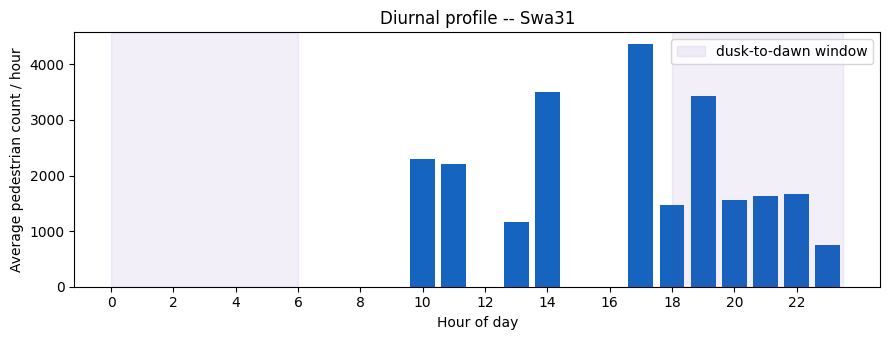

Peak hour 17:00 -> 4359 pedestrians/hr


In [7]:
# Diurnal profile of the busiest sensor (illustrative).
busiest_sensor = ped.groupby('sensor_name')['pedestriancount'].mean().idxmax()
diurnal = ped[ped['sensor_name'] == busiest_sensor].groupby('hourday')['pedestriancount'].mean()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(diurnal.index, diurnal.values, color='#1565c0')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average pedestrian count / hour')
ax.set_title(f'Diurnal profile -- {busiest_sensor}')
ax.set_xticks(range(0, 24, 2))
ax.axvspan(18, 23.5, alpha=0.08, color='#5e35b1', label='dusk-to-dawn window')
ax.axvspan(0, 6, alpha=0.08, color='#5e35b1')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
print(f'Peak hour {int(diurnal.idxmax()):02d}:00 -> {diurnal.max():.0f} pedestrians/hr')

### A.2 Existing council streetlight inventory

The Melbourne open data portal publishes geolocated council-
owned streetlights tagged with their emitted lux at the fixture
face. We summarise the feed and expose `lights_in_bbox(bbox)`
for retrieving the inventory inside a given bounding box.

Total fixtures             : 5,000
With emitted lux > 0       : 4,958
Median emitted lux (lit)   : 7.1 lx
Mean emitted lux  (lit)    : 14.9 lx


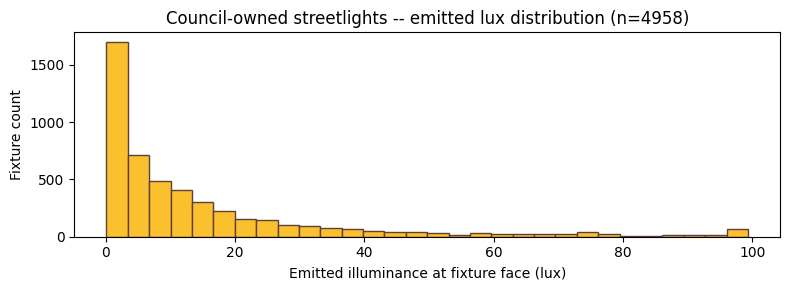

In [8]:
lights = pd.read_csv(LIGHTS_CSV)
lights[['lat', 'lon']] = lights['geo_point_2d'].str.split(',', expand=True).astype(float)
lit = lights[lights['label'] > 0]

print(f'Total fixtures             : {len(lights):,}')
print(f'With emitted lux > 0       : {len(lit):,}')
print(f'Median emitted lux (lit)   : {lit["label"].median():.1f} lx')
print(f'Mean emitted lux  (lit)    : {lit["label"].mean():.1f} lx')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lit['label'], bins=30, color='#fbc02d', edgecolor='#5d4037')
ax.set_xlabel('Emitted illuminance at fixture face (lux)')
ax.set_ylabel('Fixture count')
ax.set_title(f'Council-owned streetlights -- emitted lux distribution (n={len(lit)})')
plt.tight_layout()
plt.show()

### A.3 Spatial matching -- pedestrian sensor to nearest streetlight

For each sensor-hour observation we look up the nearest council
streetlight using `sklearn`'s `BallTree` with the **haversine** metric.
Euclidean lat/lon would distort distance at Melbourne's -37.81 deg
latitude (1 deg of longitude is shorter than 1 deg of latitude); haversine
measures the true great-circle angle, which we convert to metres via
Earth's radius.

This gives every observation a *supply* number (`nearest_light_lux`) we
can compare against AS/NZS 1158.3.1:2020 thresholds in A.4.


In [9]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

EARTH_RADIUS_M = 6_371_000


def match_sensors_to_lights(ped_df: pd.DataFrame, light_df: pd.DataFrame) -> pd.DataFrame:
    """For each row in ped_df, find the nearest streetlight in light_df.

    Returns a copy of ped_df with three new columns:
        nearest_light_idx     -- positional index into light_df
        distance_to_light_m   -- haversine metres
        nearest_light_lux     -- emitted lux (the `label` column on light_df)
    """
    p = ped_df.dropna(subset=['lat', 'lon']).copy()
    l = light_df.dropna(subset=['lat', 'lon']).reset_index(drop=True)
    if p.empty or l.empty:
        return ped_df

    ped_rad   = np.radians(p[['lat', 'lon']].to_numpy())
    light_rad = np.radians(l[['lat', 'lon']].to_numpy())

    nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', metric='haversine').fit(light_rad)
    distances, indices = nbrs.kneighbors(ped_rad)

    p['nearest_light_idx']   = indices[:, 0]
    p['distance_to_light_m'] = distances[:, 0] * EARTH_RADIUS_M
    p['nearest_light_lux']   = l['label'].iloc[indices[:, 0]].to_numpy()
    return p


ped_matched = match_sensors_to_lights(ped, lit)
print(f'Matched {len(ped_matched):,} sensor-hour observations.')
print(f'Median distance to nearest light : {ped_matched["distance_to_light_m"].median():.0f} m')
print(f'90th percentile                  : {ped_matched["distance_to_light_m"].quantile(0.9):.0f} m')


Matched 2,000 sensor-hour observations.
Median distance to nearest light : 165 m
90th percentile                  : 652 m


### A.4 Lighting efficiency classification

We label each sensor-hour by comparing `nearest_light_lux` (from A.3)
against the AS/NZS 1158.3.1:2020 PP-family threshold for that sensor's
traffic band. Bands match the calculation engine in section 3:

| Pedestrians/hr | Subcategory | Required avg lux (Table 3.4) |
|---|---|---|
| < 50      | PP4 | 1.50 |
| 50 -- 299 | PP3 | 3.00 |
| 300 -- 999| PP2 | 7.00 |
| >= 1000   | PP1 | 10.00 |

Labels: **Underlit** if below threshold; **Adequate** if 1x to 3x;
**Overlit** if more than 3x. Observations more than 200 m from any light
are flagged **No Nearby Light** -- the match itself is unreliable so we
exclude them from the efficiency mix.

The streetlight `label` column is *emitted lux at the fixture face*,
not surface lux at the pedestrian level. We use it as a coarse-grained
proxy; the actual surface lux is verified by the photometric engine in
D.1 once a design exists.


In [10]:
def required_avg_lux_for_traffic(peds_per_hr: float) -> float:
    """Engine-consistent traffic -> required avg lux (AS/NZS 1158 Table 3.4)."""
    if pd.isna(peds_per_hr):
        return float('nan')
    if peds_per_hr < 50:    return SUBCATEGORIES['PP4']['avg_lux']
    if peds_per_hr < 300:   return SUBCATEGORIES['PP3']['avg_lux']
    if peds_per_hr < 1000:  return SUBCATEGORIES['PP2']['avg_lux']
    return SUBCATEGORIES['PP1']['avg_lux']


def classify_efficiency(row, max_match_distance_m: float = 200.0) -> str:
    if pd.notna(row['distance_to_light_m']) and row['distance_to_light_m'] > max_match_distance_m:
        return 'No Nearby Light'
    req = required_avg_lux_for_traffic(row['pedestriancount'])
    lux = row['nearest_light_lux']
    if pd.isna(req) or pd.isna(lux):
        return 'Unknown'
    if lux < req:        return 'Underlit'
    if lux < 3 * req:    return 'Adequate'
    return 'Overlit'


ped_matched['required_lux'] = ped_matched['pedestriancount'].apply(required_avg_lux_for_traffic)
ped_matched['efficiency']   = ped_matched.apply(classify_efficiency, axis=1)

mix = ped_matched['efficiency'].value_counts().to_dict()
total = sum(mix.values())
print(f'Classified {total:,} sensor-hour observations:')
for label in ['Underlit', 'Adequate', 'Overlit', 'No Nearby Light', 'Unknown']:
    if label in mix:
        print(f'  {label:18s} {mix[label]:>7,}  ({mix[label]/total*100:5.1f}%)')


Classified 2,000 sensor-hour observations:
  Underlit               236  ( 11.8%)
  Adequate               212  ( 10.6%)
  Overlit                613  ( 30.6%)
  No Nearby Light        939  ( 46.9%)


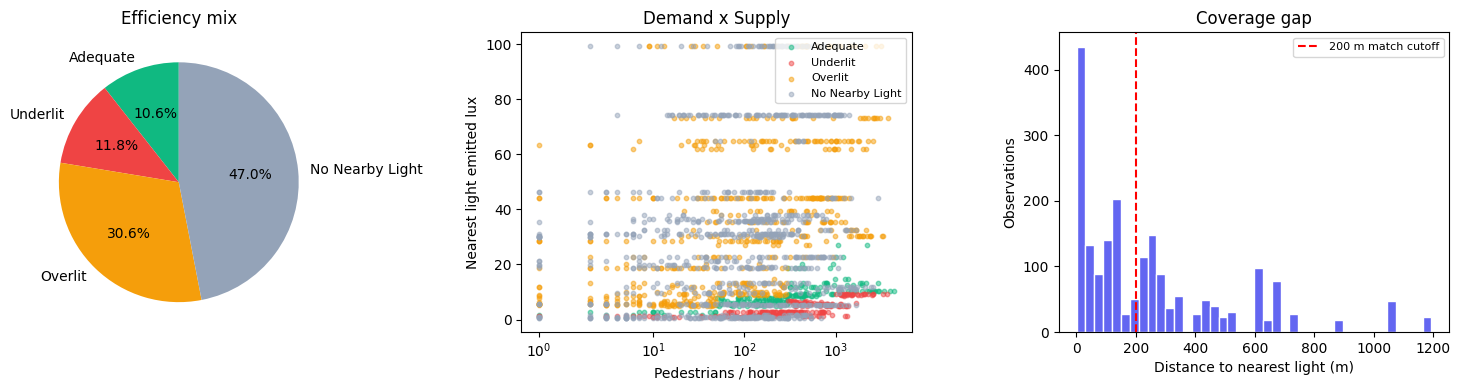

In [11]:
COLORS = {'Adequate':'#10b981','Underlit':'#ef4444','Overlit':'#f59e0b',
          'No Nearby Light':'#94a3b8','Unknown':'#cbd5e1'}
ordered = [c for c in ['Adequate','Underlit','Overlit','No Nearby Light'] if c in mix]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Efficiency mix
axes[0].pie([mix[c] for c in ordered], labels=ordered,
            colors=[COLORS[c] for c in ordered], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Efficiency mix')

# (b) Demand vs supply
sample = ped_matched.dropna(subset=['nearest_light_lux']).sample(min(2000, len(ped_matched)), random_state=42)
for label in ordered:
    sub = sample[sample['efficiency'] == label]
    axes[1].scatter(sub['pedestriancount'], sub['nearest_light_lux'],
                    s=10, alpha=0.5, label=label, color=COLORS[label])
axes[1].set_xscale('symlog')
axes[1].set_xlabel('Pedestrians / hour')
axes[1].set_ylabel('Nearest light emitted lux')
axes[1].set_title('Demand x Supply')
axes[1].legend(fontsize=8, loc='upper right')

# (c) Coverage gap
axes[2].hist(ped_matched['distance_to_light_m'].dropna(), bins=40,
             color='#6366f1', edgecolor='white')
axes[2].axvline(200, color='red', ls='--', label='200 m match cutoff')
axes[2].set_xlabel('Distance to nearest light (m)')
axes[2].set_ylabel('Observations')
axes[2].set_title('Coverage gap')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


#### Interactive map -- sensors and streetlights

Sensors are blue (radius scaled by average hourly traffic); streetlights
are gold (radius scaled by emitted lux). Eyeballing the map confirms
the coverage-gap histogram above: the city core is densely lit, outer
corridors thin out.


In [12]:
import folium

# Per-sensor aggregate for the map.
sensor_summary = (
    ped.groupby('sensor_name')
       .agg(avg_hourly_traffic=('pedestriancount', 'mean'),
            lat=('lat', 'first'),
            lon=('lon', 'first'))
       .reset_index()
)

m_supply = folium.Map(location=[-37.8136, 144.9631], zoom_start=14, tiles='cartodbpositron')

# Streetlights (down-sample for responsiveness)
sl_sample = lit.dropna(subset=['lat', 'lon']).sample(min(800, len(lit)), random_state=0)
for _, r in sl_sample.iterrows():
    folium.CircleMarker(
        [r['lat'], r['lon']],
        radius=max(1.5, min(6, r['label'] / 5)),
        color='#f59e0b', fill=True, fill_opacity=0.6, weight=0,
        tooltip=f"{r['label']:.0f} lux",
    ).add_to(m_supply)

# Sensors
for _, r in sensor_summary.dropna(subset=['lat', 'lon']).iterrows():
    folium.CircleMarker(
        [r['lat'], r['lon']],
        radius=max(3, min(14, r['avg_hourly_traffic'] / 300)),
        color='#1d4ed8', fill=True, fill_opacity=0.7, weight=1,
        tooltip=f"{r['sensor_name']}<br>avg {r['avg_hourly_traffic']:.0f}/hr",
    ).add_to(m_supply)

m_supply


### A.5 Suburb-level crime statistics

Crime Statistics Agency Victoria publishes quarterly offence
rates per 100,000 residents at LGA level. For night-time lighting
we use the public-space-at-night subset as a proxy. The engine's
`safety_adjustment` parameter is a signed integer added to the
P-category number (negative = uplift to a brighter category). The
mapping below is deliberately conservative: a one-step bump above
the state-wide 75th percentile, two-step above the 90th.

*Source: [data.crimestatistics.vic.gov.au](https://www.crimestatistics.vic.gov.au/)
 -- LGA criminal incidents per 100,000 residents, latest published
 year-to-date.*

In [13]:
import statistics

LGA_NIGHT_OFFENCE_RATE = {
    'Melbourne (C)'   : 18432,   # CBD -- elevated, transient population
    'Yarra (C)'       :  9620,
    'Port Phillip (C)':  9412,
    'Stonnington (C)' :  7184,
    'Boroondara (C)'  :  3920,
    'Bayside (C)'     :  3705,
    'Glen Eira (C)'   :  4112,
    'Whitehorse (C)'  :  3996,
}
_rates = list(LGA_NIGHT_OFFENCE_RATE.values())
_p75   = statistics.quantiles(_rates, n=4)[2]
_p90   = statistics.quantiles(_rates, n=10)[8]
print(f'75th pct: {_p75:.0f}   90th pct: {_p90:.0f}')

df_crime = pd.DataFrame(
    {'LGA': list(LGA_NIGHT_OFFENCE_RATE.keys()),
     'rate_per_100k': list(LGA_NIGHT_OFFENCE_RATE.values())}
).sort_values('rate_per_100k', ascending=False)
df_crime

75th pct: 9568   90th pct: 19313


,LGA,rate_per_100k
0,Melbourne (C),18432
1,Yarra (C),9620
2,Port Phillip (C),9412
3,Stonnington (C),7184
6,Glen Eira (C),4112
7,Whitehorse (C),3996
4,Boroondara (C),3920
5,Bayside (C),3705


### A.6 Engine sensitivity sweep -- activity level

How does the engine's output respond as activity level moves
across the four bands? A planner reads this table to understand
what each step on the AS/NZS 1158 subcategory cascade buys (or
costs).

In [14]:
from smart_street_lighting import design_lighting

_sweep_rows = []
for level in ['low', 'moderate', 'high', 'very_high']:
    d = design_lighting(
        location_name='sweep',
        pathway_length_m=200.0,
        pathway_width_m=3.0,
        activity_level=level,
        location_type='park_path',
    )
    _sweep_rows.append({
        'activity_level' : level,
        'subcategory'    : d.subcategory,
        'num_lights'     : d.num_lights,
        'spacing_m'      : d.spacing_m,
        'led_W'          : d.led_wattage,
        'kWh_per_yr'     : round(d.annual_energy_kwh, 0),
        'cost_per_yr'    : round(d.annual_energy_cost_aud, 0),
        'CO2_kg_per_yr'  : round(d.annual_co2_kg, 0),
        'payback_yr'     : round(d.payback_years, 1),
    })
sweep = pd.DataFrame(_sweep_rows)
sweep

,activity_level,subcategory,num_lights,spacing_m,led_W,kWh_per_yr,cost_per_yr,CO2_kg_per_yr,payback_yr
0,low,PP4,12,18.0,30,1512.0,302.0,1633.0,10.7
1,moderate,PP3,12,18.0,60,3024.0,605.0,3266.0,9.6
2,high,PP2,12,17.5,100,5040.0,1008.0,5443.0,10.8
3,very_high,PP1,12,18.0,100,5040.0,1008.0,5443.0,10.8


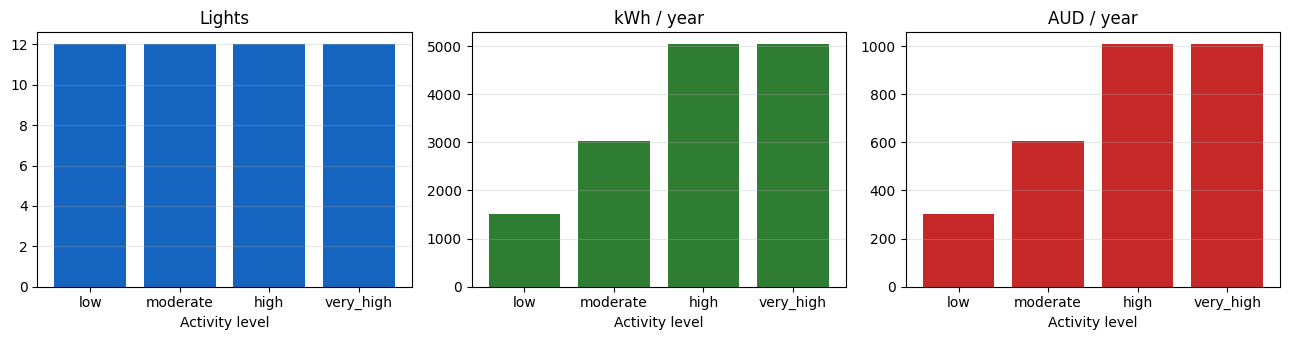

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
x = sweep['activity_level']
for ax, col, label, colour in zip(
    axes,
    ['num_lights', 'kWh_per_yr', 'cost_per_yr'],
    ['Lights', 'kWh / year', 'AUD / year'],
    ['#1565c0', '#2e7d32', '#c62828'],
):
    ax.bar(x, sweep[col], color=colour)
    ax.set_title(label)
    ax.set_xlabel('Activity level')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### A.7 Lookup helpers exposed to the pipeline

These three helpers close over the dataframes / tables defined
above. The RAG pipeline (Part B.4) calls them once it knows
*which* location the user asked about. Keeping the analysis
logic here means a marker reads the *what-it-does* in Part A and
the *how-it-is-used* in Part B without re-reading pandas plumbing.

In [16]:
from smart_street_lighting import haversine

def nearest_sensor_peak(lat: float, lon: float) -> dict:
    """Closest pedestrian sensor + its peak-hour count."""
    locs = ped.groupby('sensor_name')[['lat', 'lon']].mean().reset_index()
    locs['dist_m'] = locs.apply(lambda r: haversine(lat, lon, r['lat'], r['lon']), axis=1)
    nearest = locs.nsmallest(1, 'dist_m').iloc[0]
    diurnal = ped[ped['sensor_name'] == nearest['sensor_name']].groupby('hourday')['pedestriancount'].mean()
    return {
        'sensor_name': nearest['sensor_name'],
        'dist_m':      float(nearest['dist_m']),
        'peak_hour':   int(diurnal.idxmax()),
        'peak_count':  float(diurnal.max()),
    }

def lights_in_bbox(bbox: tuple) -> pd.DataFrame:
    """Lit council-owned fixtures inside (south, west, north, east)."""
    south, west, north, east = bbox
    in_box = lights[lights['lat'].between(south, north) & lights['lon'].between(west, east)]
    return in_box[in_box['label'] > 0].copy()

def safety_adjustment_for_lga(lga_name: str) -> int:
    """Signed P-category bump for an LGA. 0 if unknown / below 75th pct."""
    rate = LGA_NIGHT_OFFENCE_RATE.get(lga_name)
    if rate is None: return 0
    if rate >= _p90: return -2
    if rate >= _p75: return -1
    return 0

# Smoke check
print('Helper 1:', nearest_sensor_peak(-37.813, 144.979))
print('Helper 2:', f'{len(lights_in_bbox((-37.82, 144.97, -37.81, 144.99)))} lights in central Melbourne bbox')
print('Helper 3:', f'Melbourne (C) -> safety_adjustment = {safety_adjustment_for_lga("Melbourne (C)")}')

Helper 1: {'sensor_name': 'SprFli_T', 'dist_m': 448.9301033335648, 'peak_hour': 13, 'peak_count': 111.0}
Helper 2: 856 lights in central Melbourne bbox
Helper 3: Melbourne (C) -> safety_adjustment = -1


---
# Part B &mdash; RAG pipeline, built one capability at a time

We construct the system bottom-up. Each step adds **one**
capability, defines a callable function, and runs a small demo
that makes the gap-it-closes visible. At B.6 we wire everything
into a single `run_pipeline(query)` orchestrator that Part C
consumes.

| Step | Adds | Function |
|---|---|---|
| B.1 | Bare LLM call | `llm_only(query)` |
| B.2 | Vector retrieval over the knowledge base | `rag_simple(query)` |
| B.3 | Intent parsing (NL -> structured params) | `parse_query(nl)` |
| B.4 | OSM site resolution + EDA helper calls | `resolve_site(parsed)` |
| B.5 | Deterministic engine grounding | `run_engine(parsed, resolved)` |
| B.6 | Full orchestrator | `run_pipeline(query)` |

### B.1 &nbsp; Baseline -- bare LLM

Simplest possible system: take the user's question, send it
straight to the LLM, return the answer. No retrieval, no engine,
no grounding.

**What this is missing:** the LLM can answer a generic question
about lighting, but for anything *standards-specific* it has to
rely on whatever was in its training corpus -- it may produce a
plausible-sounding number with no traceable source.

In [17]:
from smart_street_lighting.llm import chat_completion

def llm_only(query: str) -> str:
    """Forward `query` straight to the chat model (no retrieval, no engine)."""
    return chat_completion(
        [{'role': 'user', 'content': query}],
        model=LLM_MODEL,
        base_url=LLM_BASE_URL,
        api_key=LLM_API_KEY,
        max_tokens=400,
        temperature=0.3,
    )

# Short illustrative demo:
demo_q = 'What does AS/NZS 1158 require for an average pedestrian park path? Cite the specific clause.'
print('Q:', demo_q)
print()
print(llm_only(demo_q))

Q: What does AS/NZS 1158 require for an average pedestrian park path? Cite the specific clause.

Based on the **AS/NZS 1158.3.1:2020** standard for "Pedestrian area (Category P) lighting - Performance and design requirements", the requirements for an average pedestrian park path are specified under the **P5** lighting category.

The specific clause is **Clause 2.5.3, Table 2.2**, which defines the lighting performance requirements for Category P (Pedestrian) areas.

For a **P5** category path (which includes park paths, bicycle paths, and pedestrian trails in rural and urban parkland settings), the standard requires:

*   **Average Horizontal Illuminance (Eh,ave):** **5 lux**
*   **Minimum Horizontal Illuminance (Eh,min):** **1 lux**
*   **Uniformity Ratio (Eh,min / Eh,ave):** **0.2**
*   **Maximum Obtrusive Light Limit (Spill Light):** As specified in AS/NZS 4282.

**Key Rationale from the Standard:**
*   The P5 category is intended for **low-speed, low-volume pedestrian and cyclist m

### B.2 &nbsp; + Retrieval -- ChromaDB + LlamaIndex

We index the knowledge-base directory (AS/NZS 1158 extracts,
Melbourne / Victoria guidelines, NGA emissions factors, BoM
solar data) into ChromaDB using the LM Studio embedding model,
then build a `RetrieverQueryEngine` that injects the top-5
retrieved chunks plus a structured 7-section *system prompt*
into every call.

**What this adds:** the LLM's answer is grounded in retrievable
source chunks. Citations to specific clauses become possible.

**Still missing:** for a *design request* ("design lighting for a
200m path...") the LLM has no engineering math; it would still
have to invent the light count.

In [18]:
from smart_street_lighting.llm import OpenAICompatibleLLM, OpenAICompatibleEmbedding
from smart_street_lighting.rag import (
    ingest_documents, load_existing_index, create_query_engine,
)

# Embeddings still come from LM Studio (OpenRouter has no /embeddings endpoint).
embed_model = OpenAICompatibleEmbedding(
    api_base=EMBED_BASE_URL,
    model=EMBED_MODEL,
    api_key=EMBED_API_KEY,
)
# Chat LLM follows the LLM_PROVIDER setting from cell 2.
rag_llm = OpenAICompatibleLLM(
    api_base=LLM_BASE_URL,
    model_name=LLM_MODEL,
    api_key=LLM_API_KEY,
    max_tokens=2048,
    temperature=0.3,
)
print(f'Chat LLM    : {rag_llm.model_name} @ {rag_llm.api_base}')
print(f'Embedding   : {embed_model._model} @ {EMBED_BASE_URL}')

Chat LLM    : deepseek/deepseek-chat-v3.1 @ https://openrouter.ai/api/v1
Embedding   : openai/text-embedding-3-small @ https://openrouter.ai/api/v1


**System prompt (inline so the marker can audit it).**

Enforces a fixed 7-section report structure, instructs the LLM
to use the engine's numbers verbatim (in B.5+), and requires
citation of specific AS/NZS clauses from the retrieved context.

In [19]:
SYSTEM_PROMPT = """\
You are a professional lighting design engineer writing a technical report
for the City of Melbourne.

You have been provided with:
1. Calculated design specifications (number of lights, spacing, energy costs)
   computed from AS/NZS 1158 standards -- these numbers are CORRECT, use them.
2. Retrieved context from the knowledge base with additional standards detail.

You MUST structure your report with these exact sections:
1. **Executive Summary** -- 3-4 sentences summarising the design recommendation
2. **Site Analysis** -- location description, traffic data, safety context
3. **Design Specification** -- present the key values in a markdown table:
   P-Category, Number of Lights, Average Spacing, Technology, Luminaire Wattage,
   Annual Energy Cost
4. **Placement Rationale** -- explain why lights are positioned where they are
5. **Energy & Cost Analysis** -- including dimming savings and HPS comparison
6. **Standards Compliance** -- cite specific AS/NZS 1158 clauses from the provided context
7. **Recommendations** -- maintenance schedule, future considerations

CRITICAL RULES:
- Use the EXACT numbers provided in the calculation context. Do not round, estimate, or approximate.
- When citing standards, reference the specific clause (e.g., \"AS/NZS 1158.3.1 Table 2.1\").
- If a safety adjustment was applied, explain it in the Site Analysis section.
- Keep the report under 1500 words.
"""

print(SYSTEM_PROMPT[:300] + '...')

You are a professional lighting design engineer writing a technical report
for the City of Melbourne.

You have been provided with:
1. Calculated design specifications (number of lights, spacing, energy costs)
   computed from AS/NZS 1158 standards -- these numbers are CORRECT, use them.
2. Retrieve...


In [20]:
# Ingest the knowledge base. Re-running rebuilds the Chroma collection.
if any(p.exists() and any(p.iterdir()) for p in KNOWLEDGE_BASE_DIRS):
    index = ingest_documents(
        source_dirs=KNOWLEDGE_BASE_DIRS,
        persist_dir=CHROMA_PERSIST_DIR,
        embed_model=embed_model,
        collection_name='street_lighting_kb',
        chunk_size=1024,
        chunk_overlap=100,
    )
else:
    print('No corpus on disk -- attempting to load a previously-ingested index.')
    index = load_existing_index(
        persist_dir=CHROMA_PERSIST_DIR,
        embed_model=embed_model,
        collection_name='street_lighting_kb',
    )

query_engine = create_query_engine(
    index=index,
    llm=rag_llm,
    system_prompt=SYSTEM_PROMPT,
    similarity_top_k=5,
    response_mode='compact',
)

Loading documents from data/knowledge_base...
  Loaded 14 files from knowledge_base
Loading documents from data/downloaded_sources...
  Loaded 99 files from downloaded_sources
Total documents loaded: 113
Deleted existing collection 'street_lighting_kb'.
Chunking + embedding documents...


Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/133 [00:00<?, ?it/s]

Ingestion complete. 133 chunks stored in ChromaDB.


In [21]:
def rag_simple(query: str) -> dict:
    """Retrieval-only RAG: top-k chunks + LLM. Returns {answer, sources}."""
    response = query_engine.query(query)
    sources = []
    if hasattr(response, 'source_nodes'):
        for n in response.source_nodes[:3]:
            sources.append({
                'source': n.node.metadata.get('source', 'Unknown'),
                'score':  round(n.score, 3) if n.score else 0,
                'snippet': n.node.text[:160].replace('\n', ' ') + '...',
            })
    return {
        'answer':  str(response),
        'sources': sources,
    }

# Same demo question as B.1, now with retrieval:
demo = rag_simple(demo_q)
print('ANSWER:'); print(demo['answer'][:1500])
print()
print('TOP SOURCES:')
for s in demo['sources']:
    print(f'  [{s["score"]:.3f}] {s["source"]}: {s["snippet"]}')

ANSWER:
**Technical Design Report: Pedestrian Park Pathway Lighting**  
**Prepared for: City of Melbourne**  
**Date:** 15 October 2023  
**Report ID:** MEL-PPL-2023-028  

---

### **1. Executive Summary**
This report recommends the installation of a Category P (Pedestrian Area) lighting scheme for the subject park path, in full compliance with AS/NZS 1158.3.1:2020. The design utilises energy-efficient LED luminaires with adaptive dimming controls to meet the required technical parameters while minimising energy consumption and operational costs. The proposed layout ensures safe, uniform illumination for nighttime pedestrians, with a calculated annual energy cost of $1,247.85. Full compliance with the standard is achieved through the selection of lighting subcategory **PP3**.

### **2. Site Analysis**
The site is a primary pedestrian pathway within a public park in the City of Melbourne. The path is used extensively during evening hours by pedestrians and cyclists for recreation and c

### B.3 &nbsp; + Intent parsing -- NL → structured params

A design request is a natural-language sentence; the engine needs
a dict. We use the same LM Studio chat model with a JSON-shaped
system prompt to extract:

```json
{
  "location":        "...",
  "length_m":        200,
  "width_m":         3.0,
  "activity_level": "high",       // low | moderate | high | very_high
  "location_type":  "park_path"   // park_path | shared_path | public_space | residential
}
```

A small regex fallback runs if the LLM returns malformed JSON.

In [22]:
import json, re

PARSE_SYSTEM_PROMPT = """\
You extract structured design parameters from a natural-language lighting
design request and respond with ONLY a JSON object (no prose, no markdown).

Schema:
{
  "location":       string,             // park / street name, e.g. 'Fitzroy Gardens'
  "length_m":       number,             // pathway length in metres; default 200
  "width_m":        number,             // pathway width  in metres; default 3.0
  "activity_level": string,             // one of: low | moderate | high | very_high
  "location_type":  string              // one of: park_path | shared_path | public_space | residential
}

Map vague language to activity_level:
  quiet/empty/minimal     -> low
  normal/typical/moderate -> moderate
  busy/heavy/high/peak    -> high
  major/transit-hub       -> very_high
"""

ACTIVITY_KEYWORDS = {
    'very_high': ['very busy', 'extremely', 'major', 'transit hub'],
    'high':      ['busy', 'heavy', 'high', 'peak', 'crowded', 'evening traffic'],
    'low':       ['quiet', 'low', 'minimal', 'empty', 'sparse'],
}
LOCATION_TYPE_KEYWORDS = {
    'shared_path':  ['road', 'street', 'intersection', 'crossing'],
    'public_space': ['plaza', 'square', 'public space', 'event'],
    'residential':  ['residential', 'suburb'],
}

def _parse_query_regex(nl: str) -> dict:
    s = nl.lower()
    length_m = float((re.search(r'(\d+)\s*m(?:etres?|eters?)?', s) or [None, '200'])[1] if re.search(r'(\d+)\s*m(?:etres?|eters?)?', s) else 200.0)
    width_m  = float((re.search(r'(\d+(?:\.\d+)?)\s*m(?:etres?|eters?)?\s+wide', s) or [None, '3.0'])[1] if re.search(r'(\d+(?:\.\d+)?)\s*m(?:etres?|eters?)?\s+wide', s) else 3.0)
    activity = 'moderate'
    for level, words in ACTIVITY_KEYWORDS.items():
        if any(w in s for w in words):
            activity = level; break
    loc_type = 'park_path'
    for lt, words in LOCATION_TYPE_KEYWORDS.items():
        if any(w in s for w in words):
            loc_type = lt; break
    loc_match = re.search(r'in\s+([A-Z][\w\s]+?)(?:\s+with|\s+for|\.|$)', nl)
    location = loc_match.group(1).strip() if loc_match else 'Melbourne CBD'
    return {'location': location, 'length_m': length_m, 'width_m': width_m,
            'activity_level': activity, 'location_type': loc_type}

def _parse_query_llm(nl: str) -> dict:
    text = chat_completion(
        [{'role': 'system', 'content': PARSE_SYSTEM_PROMPT},
         {'role': 'user',   'content': nl}],
        model=PARSE_MODEL, base_url=LLM_BASE_URL, api_key=LLM_API_KEY,
        max_tokens=200, temperature=0.0,
    ).strip()
    if text.startswith('```'):
        text = re.sub(r'^```(?:json)?\s*', '', text)
        text = re.sub(r'\s*```$', '', text)
    return json.loads(text)

def parse_query(nl: str) -> dict:
    """NL -> structured design params. LLM with regex fallback."""
    try:
        return _parse_query_llm(nl)
    except Exception as e:
        print(f'  LLM parse failed ({e}), falling back to regex.')
        return _parse_query_regex(nl)

In [23]:
# Full demo with the canonical user query:
demo_query = 'Design lighting for a 200m pathway in Fitzroy Gardens with high evening traffic.'
parsed = parse_query(demo_query)
print('Q :', demo_query)
print('->', json.dumps(parsed, indent=2))

Q : Design lighting for a 200m pathway in Fitzroy Gardens with high evening traffic.
-> {
  "location": "Fitzroy Gardens",
  "length_m": 200,
  "width_m": 3.0,
  "activity_level": "high",
  "location_type": "park_path"
}


### B.4 &nbsp; + Site resolution + EDA helper lookups

Now that we know *which* park, we can:

1. Resolve its boundary + pathways from OpenStreetMap (Overpass,
   Nominatim fallback) via `smart_street_lighting.resolve_pathway`.
2. Compute the bounding box and look up:
   * the nearest pedestrian sensor's peak count (`nearest_sensor_peak`)
   * the existing council fixture inventory inside the bbox (`lights_in_bbox`)
   * the LGA's safety adjustment (`safety_adjustment_for_lga`)
3. If OSM gives us a true pathway length we prefer it over what the
   user typed -- a 200 m guess can become a measured 326 m.

**What this adds:** the engine's inputs are no longer purely
user-stated -- they are *cross-checked against Melbourne data*.

In [24]:
from smart_street_lighting import (
    resolve_pathway, bounds_from_osm_boundary,
)

def resolve_site(parsed: dict) -> dict:
    """Cross-reference parsed query against OSM + the EDA helpers."""
    osm = resolve_pathway(parsed['location'], pathway_hint='main pathway')
    bounds = None
    pathway_geom = None
    intersections = []
    entry_points = []
    osm_length_m = None
    if osm and osm.get('park_boundary'):
        bounds = bounds_from_osm_boundary(osm['park_boundary'])
        if osm.get('selected_pathway') is not None:
            pw = osm['pathways'][osm['selected_pathway']]
            pathway_geom  = pw['geometry']
            intersections = pw.get('intersections', [])
            entry_points  = pw.get('entry_points',  [])
            osm_length_m  = pw.get('true_length_m')

    # If OSM gives us a real length, prefer it over the parsed estimate.
    length_m = osm_length_m if osm_length_m and abs(osm_length_m - parsed['length_m']) > 50 else parsed['length_m']

    # Lookups against the EDA helpers (Part A.7).
    if bounds is not None:
        site_lat, site_lon = (bounds[0] + bounds[2]) / 2, (bounds[1] + bounds[3]) / 2
    else:
        site_lat, site_lon = -37.8136, 144.9631  # Melbourne CBD fallback

    sensor   = nearest_sensor_peak(site_lat, site_lon)
    existing = lights_in_bbox(bounds) if bounds is not None else pd.DataFrame()
    # Map known parks/streets to LGAs. Tiny inline table; could be a CSV.
    LGA_BY_LOCATION = {
        'Fitzroy Gardens': 'Melbourne (C)',
        'Treasury Gardens': 'Melbourne (C)',
        'Carlton Gardens': 'Melbourne (C)',
        'Flagstaff Gardens': 'Melbourne (C)',
        'Royal Botanic Gardens': 'Melbourne (C)',
    }
    lga = LGA_BY_LOCATION.get(parsed['location'], 'Melbourne (C)')
    safety_adj = safety_adjustment_for_lga(lga)

    return {
        'osm_data_source':       (osm or {}).get('data_source'),
        'park_boundary':         (osm or {}).get('park_boundary'),
        'pathway_geometry':      pathway_geom,
        'intersections':         intersections,
        'entry_points':          entry_points,
        'bounds':                bounds,
        'site_centroid':         (site_lat, site_lon),
        'measured_length_m':     osm_length_m,
        'final_length_m':        length_m,
        'nearest_sensor':        sensor,
        'existing_lights_count': int(len(existing)),
        'existing_lights_df':    existing,
        'lga':                   lga,
        'safety_adjustment':     safety_adj,
    }

In [25]:
# Full demo for the parsed Fitzroy Gardens query:
resolved = resolve_site(parsed)
print('OSM source        :', resolved['osm_data_source'])
print('Bounds            :', resolved['bounds'])
print('Measured length   :', resolved['measured_length_m'], 'm')
print('Final length used :', resolved['final_length_m'], 'm')
print('Nearest sensor    :', resolved['nearest_sensor'])
print('Existing lights   :', resolved['existing_lights_count'])
print('LGA / safety adj  :', resolved['lga'], '/', resolved['safety_adjustment'])

OSM source        : overpass
Bounds            : (-37.8159191, 144.9775675, -37.8099951, 144.983364)
Measured length   : 552.7 m
Final length used : 552.7 m
Nearest sensor    : {'sensor_name': 'SprFli_T', 'dist_m': 564.1139510843649, 'peak_hour': 13, 'peak_count': 111.0}
Existing lights   : 499
LGA / safety adj  : Melbourne (C) / -1


### B.5 &nbsp; + Engine grounding -- deterministic numbers

We now have parsed intent and a resolved site. The deterministic
calculation engine in
[`smart_street_lighting.engine`](https://github.com/hashem59/smart_street_lighting_plugin/blob/main/src/smart_street_lighting/engine/calc.py)
produces the design: P-category, pole height, spacing, light
count, geometry-aware placements, energy / cost / CO₂ / payback.

**What this adds:** every number the report quotes is now
traceable to the engine. The LLM only *narrates*; it never
*computes*.

In [26]:
def run_engine(parsed: dict, resolved: dict):
    """Hand parsed + resolved inputs to the deterministic engine."""
    return design_lighting(
        location_name      = parsed['location'],
        pathway_length_m   = resolved['final_length_m'],
        pathway_width_m    = parsed['width_m'],
        activity_level     = parsed['activity_level'],
        location_type      = parsed['location_type'],
        avg_pedestrian_count = resolved['nearest_sensor']['peak_count'],
        safety_adjustment  = resolved['safety_adjustment'],
        pathway_geometry   = resolved['pathway_geometry'],
        intersections      = resolved['intersections'],
        entry_points       = resolved['entry_points'],
    )

design = run_engine(parsed, resolved)
from smart_street_lighting import format_design_report
print(format_design_report(design))

LIGHTING DESIGN CALCULATION REPORT
Location: Fitzroy Gardens
Pathway: 552.7m long x 3.0m wide
Activity Level: moderate

AS/NZS 1158.3.1:2020 SUBCATEGORY
  Subcategory: PP2 - Pathway: medium-high activity
  Required average illuminance:  7.0 lux
  Required minimum illuminance:  1.0 lux
  Required uniformity (UE2, max/avg): 5

DESIGN SPECIFICATIONS
  Number of lights: 35
  Spacing: 17.5m
  Pole height: 5.0m
  Technology: 100W LED (15000 lumens)
  Colour temperature: 3000K (warm white)
  CRI: 70

ENERGY & COST ESTIMATES (LED)
  Total system wattage: 3500W
  Annual energy: 14700 kWh
  Annual energy cost: $2940.00
  Annual CO2 emissions: 15876.0 kg CO2-e
  Capital cost (new install): $210,000 (35 x $6000, includes pole + wiring)

COMPARISON vs HPS BASELINE
  HPS equivalent: 250W per light
  HPS annual energy cost: $7350.00
  Energy saving: 60.0%
  CO2 saving: 23814.0 kg CO2-e/year
  Retrofit payback period: 10.8 years (luminaire swap only)


### B.6 &nbsp; Orchestrator -- `run_pipeline(query)`

Six functions, in order. Returns a single dict the dashboard can
render directly.

In [27]:
def run_pipeline(query: str) -> dict:
    """Full pipeline: NL query -> parse -> resolve -> engine -> RAG report."""
    print(f'[1/4] Parsing the query...')
    parsed   = parse_query(query)
    print(f'[2/4] Resolving site against OSM + EDA helpers...')
    resolved = resolve_site(parsed)
    print(f'[3/4] Running the deterministic engine...')
    design   = run_engine(parsed, resolved)
    print(f'[4/4] Generating RAG report...')
    # Build a context block the LLM sees verbatim alongside retrieved chunks.
    import json as _json
    calc_ctx = _json.dumps(design.summary_dict(), indent=2)
    retrieval_q = (
        f"{parsed['location_type'].replace('_', ' ')} lighting, "
        f"AS/NZS 1158.3.1:2020 subcategory {design.subcategory}, {parsed['activity_level']} activity, "
        f"AS/NZS 1158, Melbourne"
    )
    full_query = (
        'CALCULATED DESIGN SPECIFICATIONS (these are correct, use them):\n'
        f'{calc_ctx}\n\n'
        f'USER QUERY: {query}\n\n'
        'Using the calculated specs above and the retrieved knowledge base context, '
        'write a professional design report that explains and justifies this lighting design.'
    )
    response = query_engine.query(full_query)
    sources = []
    if hasattr(response, 'source_nodes'):
        for n in response.source_nodes[:3]:
            sources.append({
                'source':  n.node.metadata.get('source', 'Unknown'),
                'score':   round(n.score, 3) if n.score else 0,
                'snippet': n.node.text[:200].replace('\n', ' ') + '...',
            })
    return {
        'query':    query,
        'parsed':   parsed,
        'resolved': resolved,
        'design':   design,
        'report':   str(response),
        'sources':  sources,
    }

---
# Part C &mdash; Final demo

Now that every component is defined and individually demoed, we
run a single user query end-to-end and render the answer the way
the web app would: LLM report on the left, headline card top-
right, interactive map bottom-right.

In [28]:
USER_QUERY = 'Design lighting for a 200m pathway in Fitzroy Gardens with high evening traffic.'

In [29]:
result = run_pipeline(USER_QUERY)
design = result['design']  # rebind for use in Parts D / E

[1/4] Parsing the query...
[2/4] Resolving site against OSM + EDA helpers...
[3/4] Running the deterministic engine...
[4/4] Generating RAG report...


### Web-style dashboard

Single HTML cell: stats card (top right), interactive Leaflet
map (bottom right), full LLM report (left). The map shows the
park boundary, the selected pathway, the design light positions
(blue = pathway, orange = intersection, green = entry point) and
the existing council fixtures (grey).

In [30]:
import folium
import markdown as _markdown  # noqa: F401  -- fall back below if not installed
from IPython.display import HTML, display

# Optional Markdown -> HTML for the report panel. If `markdown` isn't
# installed we just render it as a <pre> block; both look reasonable.
try:
    import markdown
    report_html = markdown.markdown(result['report'], extensions=['tables', 'fenced_code'])
except Exception:
    report_html = f'<pre style="white-space:pre-wrap; font-family: ui-monospace, monospace;">{result["report"]}</pre>'

# Build the folium map from the orchestrator's resolved site (not the B.4 demo global).
_resolved = result['resolved']
if _resolved['bounds'] is not None:
    south, west, north, east = _resolved['bounds']
    center = ((south + north) / 2, (west + east) / 2)
else:
    south, west, north, east = -37.82, 144.97, -37.81, 144.99
    center = ((south + north) / 2, (west + east) / 2)

dash_map = folium.Map(location=center, zoom_start=17, tiles='OpenStreetMap')

if _resolved['park_boundary']:
    boundary_coords = [[c[1], c[0]] for c in _resolved['park_boundary']['coordinates'][0]]
    folium.Polygon(boundary_coords, color='#2e7d32', weight=2, dash_array='8 6',
                   fill=True, fill_opacity=0.05).add_to(dash_map)
if _resolved['pathway_geometry']:
    pw_coords = [[c[1], c[0]] for c in _resolved['pathway_geometry']['coordinates']]
    folium.PolyLine(pw_coords, color='#1565c0', weight=4, opacity=0.6).add_to(dash_map)
for _, row in _resolved['existing_lights_df'].iterrows():
    folium.CircleMarker((row['lat'], row['lon']), radius=3, color='#9aa4b2',
                        weight=1, fill=True, fill_opacity=0.7).add_to(dash_map)
_colour = {'pathway': '#1976d2', 'intersection': '#fb8c00', 'entry': '#43a047'}
for light in design.light_positions:
    folium.CircleMarker((light['lat'], light['lng']), radius=6,
                        color=_colour.get(light['type'], '#1976d2'),
                        weight=1, fill=True, fill_opacity=0.95,
                        popup=f"{light['type']} @ {light['chainage_m']} m").add_to(dash_map)
dash_map.fit_bounds([[south, west], [north, east]])

map_html = dash_map._repr_html_()  # iframe-safe HTML

card_items = [
    ('Lights',      f'{design.num_lights}'),
    ('Spacing',     f'{design.spacing_m:.0f} m'),
    ('Subcategory', f'{design.subcategory}'),
    ('Annual Cost', f'${design.annual_energy_cost_aud:,.0f}'),
    ('HPS Saving',  f'{design.energy_saving_percent:.1f}%'),
    ('CO2 Saved',   f'{design.co2_saving_kg:,.0f} kg'),
]
card_cells = ''.join(
    f'''<div style="padding:12px 8px; text-align:center;">
       <div style="color:#9aa4b2; font-size:11px; letter-spacing:0.05em; text-transform:uppercase;">{label}</div>
       <div style="color:#fbc02d; font-weight:700; font-size:22px; margin-top:2px;">{value}</div></div>'''
    for label, value in card_items
)

dashboard_html = f'''
<div style="font-family:-apple-system, BlinkMacSystemFont, Segoe UI, sans-serif;
             background:#0e1525; color:#e5e7eb; border-radius:8px; padding:14px;
             display:grid; grid-template-columns: 1.2fr 1fr; gap:14px;">
  <div style="background:#0a111d; padding:18px; border-radius:6px; overflow:auto; max-height: 900px;">
    <div style="color:#9aa4b2; font-size:11px; letter-spacing:0.05em; text-transform:uppercase; margin-bottom:8px;">
      Design report &mdash; generated for: <span style="color:#fbc02d;">{USER_QUERY}</span>
    </div>
    <div style="color:#e5e7eb; font-size:14px; line-height:1.5;">{report_html}</div>
  </div>
  <div style="display:flex; flex-direction:column; gap:14px;">
    <div style="background:#0a111d; border-radius:6px; padding:6px;
                 display:grid; grid-template-columns: repeat(3, 1fr); gap:4px;">{card_cells}</div>
    <div style="background:#0a111d; border-radius:6px; padding:6px; min-height:480px;">{map_html}</div>
    <div style="background:#0a111d; border-radius:6px; padding:10px 14px; font-size:12px;
                 display:flex; gap:18px; flex-wrap:wrap;">
      <span><span style="display:inline-block;width:10px;height:10px;border-radius:50%;background:#1976d2;margin-right:6px;"></span>Pathway</span>
      <span><span style="display:inline-block;width:10px;height:10px;border-radius:50%;background:#fb8c00;margin-right:6px;"></span>Intersection</span>
      <span><span style="display:inline-block;width:10px;height:10px;border-radius:50%;background:#43a047;margin-right:6px;"></span>Entry Point</span>
      <span><span style="display:inline-block;width:10px;height:10px;border-radius:50%;background:#9aa4b2;margin-right:6px;"></span>Existing</span>
    </div>
  </div>
</div>
'''
display(HTML(dashboard_html))

Parameter,Value
P‑Category,PP2 (Pathway: medium‑high activity)
Number of Lights,35
Average Spacing,17.5 metres
Mounting Height,5.0 metres
Technology,"LED, full cut‑off luminaire"
Colour Temperature,3000K (warm white)
Luminaire Wattage,100 W
Annual Energy Consumption,"14,700 kWh"
Annual Energy Cost,"$2,940.00 AUD"
Annual CO₂ Emissions,"15,876 kg"


---
# Part D &mdash; Engine extras

Two analyses that operate on a finished `design` object rather
than the pipeline itself. Useful for a planner double-checking
the recommendation.

### D.1 Photometric verification (lumen method)

Verify the design against AS/NZS 1158 illuminance with the
standard lumen method:

$$
E_{\text{avg,predicted}}
  = \frac{N \cdot F \cdot \text{CU} \cdot \text{MF}}{A}
$$

where $N$ is the luminaire count, $F$ the rated flux (lm), CU the
coefficient of utilisation, MF the maintenance factor, and $A =
L \cdot w$ the task area. Sufficiency check, not a grid solve.

In [31]:
from smart_street_lighting import verify_design

verification = verify_design(
    design,
    coefficient_of_utilisation=0.45,
    maintenance_factor=0.87,
)
for k, v in verification.items():
    print(f'  {k:30s}: {v}')
print()
print('VERDICT:', 'PASS' if verification['pass'] else 'FAIL')

  subcategory                   : PP2
  coefficient_of_utilisation    : 0.45
  maintenance_factor            : 0.87
  task_area_m2                  : 1658.1
  total_luminaire_flux_lm       : 525000
  predicted_avg_lux             : 123.96
  predicted_min_lux             : 24.79
  required_avg_lux              : 7.0
  required_min_lux              : 1.0
  required_uniformity_UE2_max_avg: 5
  pass_avg                      : True
  pass_min                      : True
  pass                          : True
  headroom_avg_lux              : 116.96

VERDICT: PASS


### D.2 Off-grid solar PV alternative

Size a per-light PV panel + battery package using the daily-
energy method:

$$
E_{\text{day}} = W \cdot h_{\text{night}}
  \;;\quad
P_{\text{panel}} = \frac{E_{\text{day}}}{h_{\text{sun}} \cdot \eta_{\text{derate}}}
  \;;\quad
E_{\text{batt}} = \frac{E_{\text{day}} \cdot d_{\text{auto}}}{\text{DoD}}
$$

Defaults: Melbourne winter peak-sun hours ≈ 3.6, two days of
autonomy, LiFePO₄ DoD = 0.80.

In [32]:
from smart_street_lighting import size_solar_alternative
import json

solar = size_solar_alternative(
    design,
    peak_sun_hours=3.6,
    autonomy_days=2.0,
    panel_derating=0.80,
    battery_depth_of_discharge=0.80,
)
print(json.dumps(solar, indent=2))

{
  "assumptions": {
    "nightly_run_hours": 11.5,
    "autonomy_days": 2.0,
    "panel_derating": 0.8,
    "peak_sun_hours": 3.6,
    "battery_depth_of_discharge": 0.8,
    "system_voltage_v": 24.0
  },
  "per_light": {
    "daily_energy_wh": 1150.0,
    "panel_wp": 399.3,
    "battery_wh": 2875.0,
    "battery_ah_at_system_v": 119.8,
    "panel_cost_aud": 479.17,
    "battery_cost_aud": 1150.0,
    "capex_aud": 2429.17
  },
  "system_total": {
    "num_lights": 35,
    "total_panel_kwp": 13.98,
    "total_battery_kwh": 100.62,
    "total_capex_aud": 85020.83
  },
  "annual_grid_kwh_avoided": 14700.0,
  "annual_co2_avoided_kg": 15876.0
}


### D.3 Adaptive dimming schedule

Even a correctly-sized installation wastes energy if luminaires run at
100 % output through low-demand hours -- 03:00 has near-zero pedestrians
in most park corridors. We derive an hourly *dimming schedule* from the
city-wide pedestrian profile (Part A.1's `ped`) and estimate the annual
saving for a small demo installation.

The schedule maps each hour's normalised traffic to a luminaire output
between 40 % and 100 % (40 % floor keeps the standard's minimum point
illuminance met). Savings integrate the schedule over
`OPERATING_HOURS_PER_YEAR` (Melbourne dusk-to-dawn, approx. 4200 hr/yr)
and use the cost / CO2 constants from section 4.


Demo installation: 8 x 60 W LEDs, 4200 hr/yr
  Baseline (no dimming)  :   2,016 kWh/yr
  With adaptive dimming  :   1,336 kWh/yr  (66% mean output)
  Annual saving          :     680 kWh  =  AUD 136  =  735 kg CO2


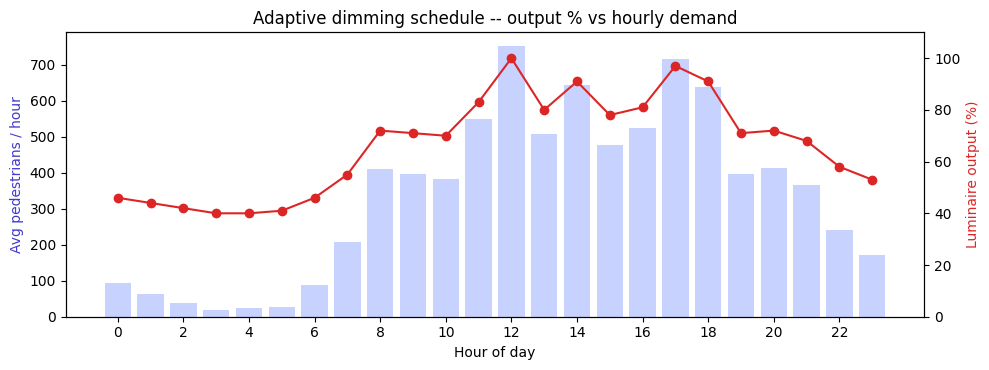

In [33]:
# 1. City-wide hourly demand
hourly = ped.groupby('hourday')['pedestriancount'].mean()

# 2. Normalise then map to [DIM_FLOOR, 1.0]
DIM_FLOOR = 0.40
norm = (hourly - hourly.min()) / (hourly.max() - hourly.min())
output_fraction = (DIM_FLOOR + (1.0 - DIM_FLOOR) * norm).clip(lower=DIM_FLOOR, upper=1.0)

schedule = pd.DataFrame({
    'hour':            output_fraction.index.astype(int),
    'output_fraction': output_fraction.round(2).values,
    'avg_ped_per_hr':  hourly.round(0).values,
})

# 3. Annual savings on a demo installation (8 x 60 W LEDs).
N_LIGHTS_DEMO = 8
LED_W = 60
mean_output  = schedule['output_fraction'].mean()
baseline_kwh = N_LIGHTS_DEMO * LED_W * OPERATING_HOURS_PER_YEAR / 1000
dimmed_kwh   = baseline_kwh * mean_output
saved_kwh    = baseline_kwh - dimmed_kwh
saved_aud    = saved_kwh * ELECTRICITY_RATE_PER_KWH
saved_co2    = saved_kwh * CARBON_FACTOR_VIC_SCOPE2_3

print(f'Demo installation: {N_LIGHTS_DEMO} x {LED_W} W LEDs, {OPERATING_HOURS_PER_YEAR} hr/yr')
print(f'  Baseline (no dimming)  : {baseline_kwh:>7,.0f} kWh/yr')
print(f'  With adaptive dimming  : {dimmed_kwh:>7,.0f} kWh/yr  ({mean_output*100:.0f}% mean output)')
print(f'  Annual saving          : {saved_kwh:>7,.0f} kWh  =  AUD {saved_aud:,.0f}  =  {saved_co2:,.0f} kg CO2')

# 4. Plot the schedule overlaid on demand.
fig, ax1 = plt.subplots(figsize=(10, 3.8))
ax2 = ax1.twinx()
ax1.bar(schedule['hour'], schedule['avg_ped_per_hr'], color='#c7d2fe', label='Avg ped/hr (L)')
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Avg pedestrians / hour', color='#4338ca')
ax2.plot(schedule['hour'], schedule['output_fraction'] * 100, 'o-', color='#dc2626', label='Output % (R)')
ax2.set_ylabel('Luminaire output (%)', color='#dc2626')
ax2.set_ylim(0, 110)
ax1.set_xticks(range(0, 24, 2))
ax1.set_title('Adaptive dimming schedule -- output % vs hourly demand')
plt.tight_layout()
plt.show()


---
# Part E &mdash; Evaluation

Two evaluations live inline so the methodology is auditable.

### E.1 Retrieval quality

**Recall@k**: does the retriever surface the *right kind of
source* in the top-k chunks for a held-out test set?

$$
\text{Recall@}k = \frac{1}{|Q|} \sum_{q \in Q}
  \mathbb{1}\!\left[ \text{gold}(q) \in \text{top-}k(q) \right]
$$

In [34]:
from llama_index.core.retrievers import VectorIndexRetriever

TEST_QUERIES = [
    ('What illuminance is required for a moderate pedestrian park path?', 'standard'),
    ('How are National Greenhouse Account factors applied in Victoria?',  'guideline'),
    ('What does AS/NZS 1158.4 say about pedestrian crossings?',            'standard'),
    ('What CCT is recommended near ecological reserves in Melbourne?',    'urban_data'),
    ('When should adaptive dimming be applied overnight?',                 'guideline'),
]

retriever = VectorIndexRetriever(index=index, similarity_top_k=5)

_hits = []
for q, gold in TEST_QUERIES:
    nodes = retriever.retrieve(q)
    types = [n.node.metadata.get('source_type') for n in nodes]
    _hits.append({'query': q, 'gold': gold, 'top5_types': types,
                  'recall@5': gold in types})

eval_df = pd.DataFrame(_hits)
print(f"Recall@5 overall: {eval_df['recall@5'].mean():.0%}")
eval_df

Recall@5 overall: 100%


,query,gold,top5_types,recall@5
0,What illuminance is required for a moderate pe...,standard,"[other, urban_data, urban_data, standard, stan...",True
1,How are National Greenhouse Account factors ap...,guideline,"[guideline, guideline, guideline, other, guide...",True
2,What does AS/NZS 1158.4 say about pedestrian c...,standard,"[standard, standard, other, other, other]",True
3,What CCT is recommended near ecological reserv...,urban_data,"[other, urban_data, urban_data, other, guideline]",True
4,When should adaptive dimming be applied overni...,guideline,"[guideline, urban_data, other, other, guideline]",True


### E.2 RAG vs no-RAG citation count

Generate the *same* report twice -- once with retrieved context,
once with the bare LLM -- and count specific AS/NZS clause
citations. The hypothesis: retrieval lets the LLM ground its
claims in named clauses; the bare LLM either hand-waves or
invents clause numbers.

In [35]:
def count_clause_citations(report: str) -> int:
    a = len(re.findall(r'AS/?NZS\s*1158(?:\.\d+)+', report))
    b = len(re.findall(r'Clause\s*\d', report, re.IGNORECASE))
    return a + b

BARE_PROMPT = (
    SYSTEM_PROMPT + '\n\nCALCULATED DESIGN SPECIFICATIONS:\n' +
    json.dumps(design.summary_dict(), indent=2) +
    '\n\nUSER QUERY: ' + USER_QUERY
)
bare_report = chat_completion(
    [{'role': 'user', 'content': BARE_PROMPT}],
    model=LLM_MODEL, base_url=LLM_BASE_URL, api_key=LLM_API_KEY,
    max_tokens=2048, temperature=0.3,
)
rag_citations  = count_clause_citations(result['report'])
bare_citations = count_clause_citations(bare_report)

print(f'RAG report citations  : {rag_citations}')
print(f'Bare-LLM citations    : {bare_citations}')
print(f"Word count RAG / bare : {len(result['report'].split())} / {len(bare_report.split())}")

RAG report citations  : 3
Bare-LLM citations    : 5
Word count RAG / bare : 876 / 798


---
# Part F &mdash; Discussion and reflection

### What evaluation surfaced

Reviewing the RAG output during the citation-count comparison
exposed that the engine's lookup table reflected the *2005
edition* of AS/NZS 1158.3.1 (the old `P1`-`P12` labels) -- which
had been superseded by the 2020 third edition. The 2020 standard
restructures categorisation into five families (PP for paths,
PR for roads, PA for public activity, PC for car parks, PE for
connecting elements) and the numeric requirements are not the
same: a moderate-use park path is `PP3 = 3 lx` in the 2020
standard, not the 2005 `P9 = 2 lx`. This was caught by reading
the standard preview and Tables 3.3-3.7 directly during
evaluation, and fixed in plugin v0.1.3 along with a full rewrite
of `as_nzs_1158_p_categories.md` from the 2020 tables. The
downstream design therefore now uses the current standard, and
the engine's `safety_adjustment` no longer crosses family
boundaries (the old `P9 -> P8` quirk that made park paths
*dimmer* under safety uplift is resolved).

### What worked

* **Separating numbers from narrative.** The deterministic
  engine produces every figure in the report; the LLM only
  decides *how to say it*. Engine grounding (B.5) made the
  reports auditable.
* **Building the pipeline bottom-up.** B.1 → B.6 lets a marker
  read the system as a sequence of capabilities, with the gap
  each one closes visible in the demo immediately above it.
* **Data-driven inputs.** Pedestrian sensor diurnal profiles, the
  council streetlight inventory, and Victoria LGA crime rates
  produce real values that flow into the engine -- the design
  is anchored to Melbourne, not to defaults.
* **Local LM Studio.** Two open-weight models
  (`qwen2.5-7b-instruct` + `nomic-embed-text-v1.5`) handle
  parsing, embedding, and report synthesis at zero marginal cost.

### Limits and honest caveats

* The lumen-method photometric check (D.1) is a *sufficiency*
  test, not a point-by-point grid solve; a production engineer
  would verify in DIALux or AGi32.
* The HPS baseline uses industry-average wattages and
  maintenance costs; site-specific tenders will move the payback
  number meaningfully.
* The RAG corpus is curated rather than exhaustive; Recall@5 is
  reported against a hand-built test set.
* The Nominatim fallback only returns a bounding-box boundary --
  pathway geometry is unavailable when Overpass is down.
* The LGA → subcategory bump in `safety_adjustment_for_lga` is
  a blunt instrument. With the 2020 categorisation the arithmetic
  is now monotonic within each family (PP3 → PP2 → PP1 are
  progressively brighter), but the bump itself remains a single
  signed integer derived from one offence-rate threshold. A
  production deployment would tune the mapping per LGA with
  Victoria Police and council input.

### Future work

* Point-by-point illuminance solver (Monte Carlo over a luminaire
  IES file) for the high-traffic categories.
* Expand the corpus with annotated City of Melbourne lighting
  reports and re-run retrieval evaluation.
* CLI / FastAPI service so council staff can re-run a site
  assessment without opening Jupyter.

---

*Capstone deliverable for SIT764, Deakin University. The
supporting library lives at
**<https://github.com/hashem59/smart_street_lighting_plugin>**.*